In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 5)
sns.set_style("whitegrid")

Load cleaned dataset

In [15]:
df = pd.read_csv("../data/processed/cleaned_encoded_job_change_data.csv")
df.head()

,city_development_index,experience,last_new_job,training_hours,target,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_size_500-999,company_size_5000-9999,company_size_<10,company_size_nan,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_nan
0,0.920,21.0,1.0,36,1.0,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,0.776,15.0,5.0,47,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.624,5.0,0.0,83,0.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,0.789,0.0,0.0,52,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.767,21.0,4.0,8,0.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [16]:
print("Dataset shape:", df.shape)

Dataset shape: (19158, 159)


Separate features and target

In [17]:
X = df.drop("target", axis=1)
y = df["target"]

In [18]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (19158, 158)
Target shape: (19158,)


Check target distribution

In [19]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

target
0.0    14381
1.0     4777
Name: count, dtype: int64
target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


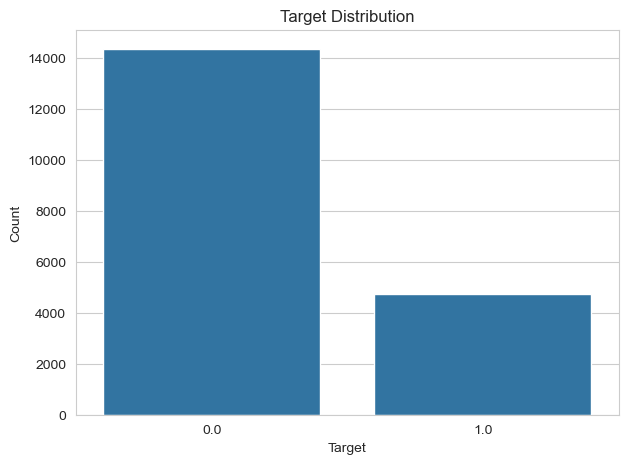

In [20]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

Train test split 

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15326, 158)
X_test shape: (3832, 158)
y_train shape: (15326,)
y_test shape: (3832,)


Feature scaling

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train the baseline Logistic Regression model

In [54]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

In [55]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Make predictions

In [56]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

Evaluate the model

In [57]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.7881
Precision: 0.6155
Recall   : 0.399
F1-score : 0.4841
ROC-AUC  : 0.8083


Classification report

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.92      0.87      2877
         1.0       0.62      0.40      0.48       955

    accuracy                           0.79      3832
   macro avg       0.72      0.66      0.68      3832
weighted avg       0.77      0.79      0.77      3832



Confusion matrix

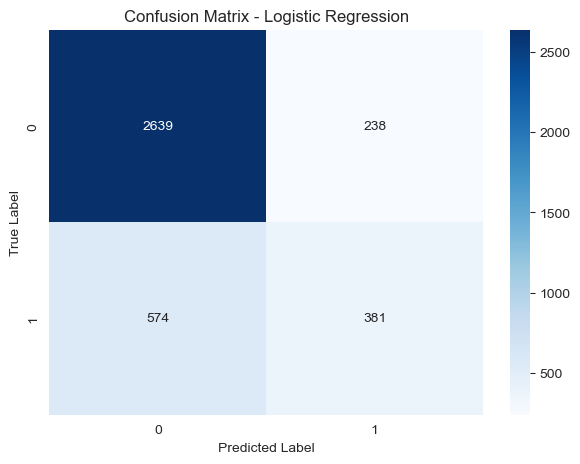

In [59]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

ROC curve

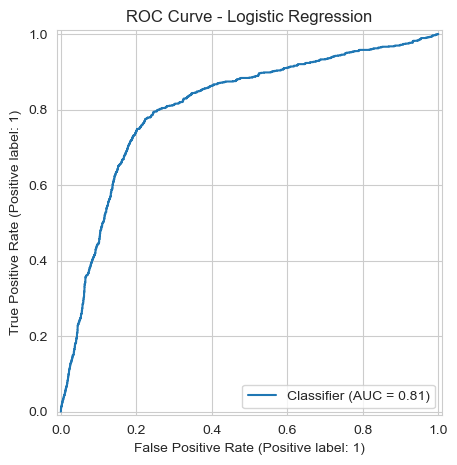

In [60]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Logistic Regression")
plt.show()

Cross-validation score

In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.42926829 0.45742092 0.40982218 0.45498392 0.44570502]
Mean CV F1 score: 0.4394400697974465


Hyperparameter tuning

In [62]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

In [63]:
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [64]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best Cross-Validation F1 Score: 0.610202133368625


Train best tuned model

In [65]:
best_log_reg = grid_search.best_estimator_
best_log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Predict with tuned model

In [66]:
y_pred_best = best_log_reg.predict(X_test_scaled)
y_prob_best = best_log_reg.predict_proba(X_test_scaled)[:, 1]

Evaluate tuned model

In [67]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

print("Tuned Logistic Regression Performance")
print("Accuracy :", round(accuracy_best, 4))
print("Precision:", round(precision_best, 4))
print("Recall   :", round(recall_best, 4))
print("F1-score :", round(f1_best, 4))
print("ROC-AUC  :", round(roc_auc_best, 4))

Tuned Logistic Regression Performance
Accuracy : 0.7704
Precision: 0.5265
Recall   : 0.7801
F1-score : 0.6287
ROC-AUC  : 0.8093


Classification report for tuned model

In [68]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

         0.0       0.91      0.77      0.83      2877
         1.0       0.53      0.78      0.63       955

    accuracy                           0.77      3832
   macro avg       0.72      0.77      0.73      3832
weighted avg       0.82      0.77      0.78      3832



Confusion matrix for tuned model

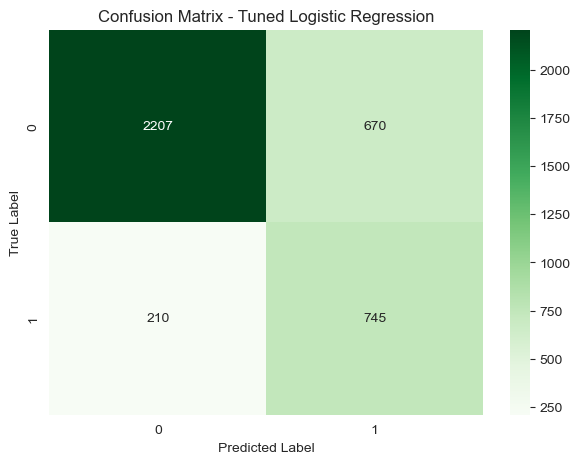

In [69]:
cm_best = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

ROC curve for tuned model

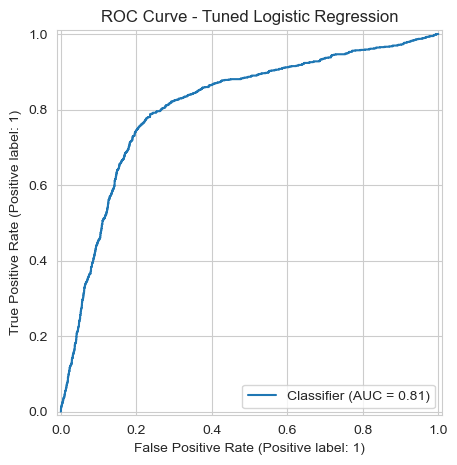

In [70]:
RocCurveDisplay.from_predictions(y_test, y_prob_best)
plt.title("ROC Curve - Tuned Logistic Regression")
plt.show()

Feature importance using coefficients

In [71]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_log_reg.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(by="Absolute_Coefficient", ascending=False)

coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
67,city_city_21,0.423159,0.423159
151,company_size_nan,0.356616,0.356616
0,city_development_index,-0.340924,0.340924
133,education_level_High School,-0.171339,0.171339
157,company_type_nan,0.170198,0.170198
1,experience,-0.144856,0.144856
136,education_level_Primary School,-0.139987,0.139987
143,major_discipline_nan,-0.137475,0.137475
33,city_city_136,-0.130072,0.130072
144,company_size_100-500,-0.128736,0.128736


Plot top influential feature

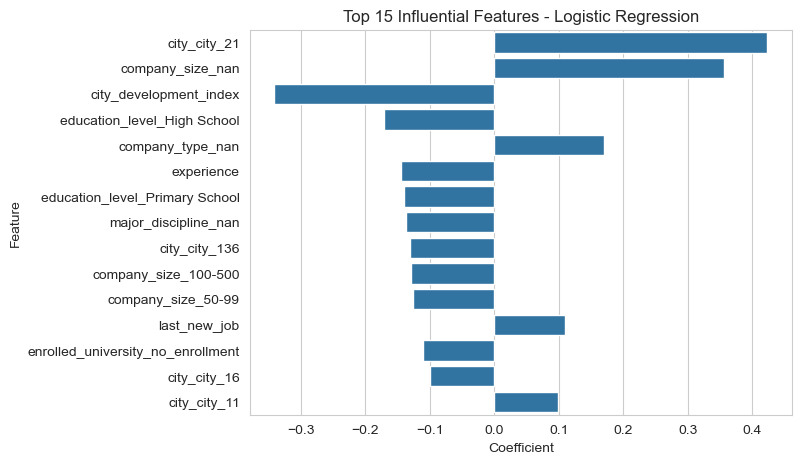

In [72]:
top_features = coefficients.head(15)

sns.barplot(data=top_features, x="Coefficient", y="Feature")
plt.title("Top 15 Influential Features - Logistic Regression")
plt.show()

Compare baseline and tuned model

In [73]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline": [accuracy, precision, recall, f1, roc_auc],
    "Tuned Model": [accuracy_best, precision_best, recall_best, f1_best, roc_auc_best]
})

comparison_df

,Metric,Baseline,Tuned Model
0,Accuracy,0.788100,0.770355
1,Precision,0.615509,0.526502
2,Recall,0.398953,0.780105
3,F1-score,0.484117,0.628692
4,ROC-AUC,0.808282,0.809263


Save results to CSV

In [74]:
comparison_df.to_csv("logistic_regression_results.csv", index=False)
coefficients.to_csv("logistic_regression_coefficients.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


Final summary

## Logistic Regression Summary

- The cleaned and encoded dataset was loaded successfully.
- Features and target were separated.
- The data was split into training and testing sets using stratified sampling.
- Standardization was applied because Logistic Regression is sensitive to feature scaling.
- A baseline Logistic Regression model was trained and evaluated.
- Hyperparameter tuning was performed using GridSearchCV.
- The tuned model was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrix, and ROC curve.
- Feature coefficients were analyzed to understand the most influential variables.